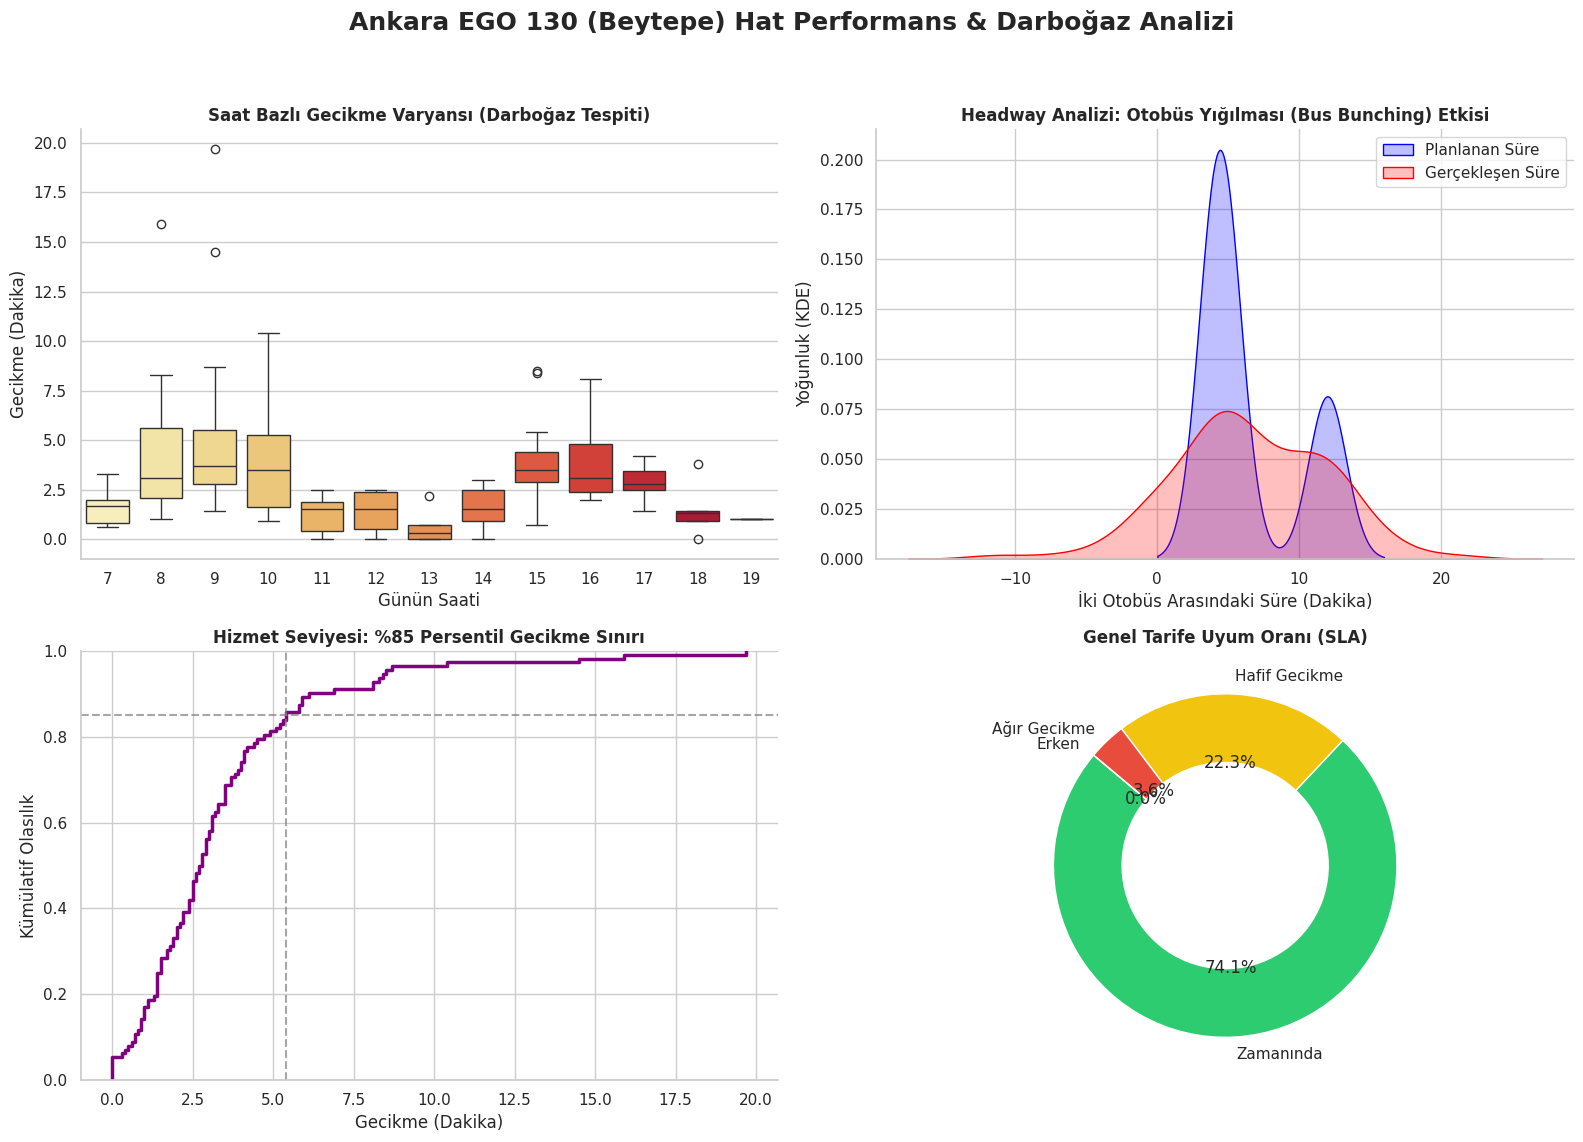

Toplam Sefer Sayısı: 112
Sabah Pik Saat (08-10) Ortalama Gecikme: 4.7 dk
Tespit Edilen 'Bus Bunching' (Peş peşe gelme) Vaka Sayısı: 21


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# BÖLÜM 1: GERÇEKÇİ EGO 130 HATTI VERİ SİMÜLASYONU (DATA GENERATION)
# =====================================================================
np.random.seed(42)
start_time = datetime.strptime("07:00", "%H:%M")
end_time = datetime.strptime("19:00", "%H:%M")

scheduled_times = []
current_time = start_time

# Saatlere göre dinamik sefer sıklığı (Pik saatlerde sık, öğlen seyrek)
while current_time <= end_time:
    scheduled_times.append(current_time)
    hour = current_time.hour
    if 8 <= hour <= 10:    # Sabah zirve (Metro -> Kampüs)
        current_time += timedelta(minutes=4)
    elif 15 <= hour <= 17: # Akşam zirve (Kampüs -> Metro)
        current_time += timedelta(minutes=5)
    else:                  # Normal saatler
        current_time += timedelta(minutes=12)

df = pd.DataFrame({'Planlanan_Zaman': scheduled_times})
df['Saat_Dilimi'] = df['Planlanan_Zaman'].dt.hour

# Gerçekleşen varışları hesapla (Gecikmeler Lognormal dağılımla simüle edilir)
# Pik saatlerde (8-10) metrodan inen yolcu kalabalığı gecikmeyi artırır
def gecikme_uret(saat):
    if 8 <= saat <= 10:
        return max(0, np.random.lognormal(mean=1.5, sigma=0.8)) # Yüksek gecikme riski
    elif 15 <= saat <= 17:
        return max(0, np.random.lognormal(mean=1.2, sigma=0.6)) # Orta gecikme riski
    else:
        return max(0, np.random.normal(loc=1, scale=1.5))       # Düşük risk

df['Gecikme_Dakika'] = df['Saat_Dilimi'].apply(gecikme_uret).round(1)
df['Gerceklesen_Zaman'] = df['Planlanan_Zaman'] + pd.to_timedelta(df['Gecikme_Dakika'], unit='m')

# =====================================================================
# BÖLÜM 2: OPERASYONEL METRİKLERİN HESAPLANMASI (FEATURE ENGINEERING)
# =====================================================================
# Headway: İki otobüs arasındaki gerçek süre (Bus Bunching analizi için kritik)
df['Planlanan_Headway'] = df['Planlanan_Zaman'].diff().dt.total_seconds() / 60
df['Gercek_Headway'] = df['Gerceklesen_Zaman'].diff().dt.total_seconds() / 60

# Otobüs Yığılması (Bus Bunching) Tespiti: Peş peşe gelen otobüsler (< 2 dk)
df['Yigilma_Var_Mi'] = df['Gercek_Headway'] < 2.0

# Zaman Çizelgesi Güvenilirliği (On-Time Performance)
# -1 ile +4 dakika arası zamanında kabul edilir
df['Durum'] = pd.cut(df['Gecikme_Dakika'],
                     bins=[-float('inf'), -1, 4, 10, float('inf')],
                     labels=['Erken', 'Zamanında', 'Hafif Gecikme', 'Ağır Gecikme'])

# =====================================================================
# BÖLÜM 3: PROFESYONEL VERİ GÖRSELLEŞTİRME (DASHBOARD)
# =====================================================================
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Ankara EGO 130 (Beytepe) Hat Performans & Darboğaz Analizi', fontsize=18, fontweight='bold', y=0.98)

# 1. Grafik: Saatlere Göre Gecikme Dağılımı (Boxplot)
ax1 = plt.subplot(2, 2, 1)
sns.boxplot(x='Saat_Dilimi', y='Gecikme_Dakika', data=df, palette='YlOrRd', ax=ax1)
ax1.set_title('Saat Bazlı Gecikme Varyansı (Darboğaz Tespiti)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Günün Saati')
ax1.set_ylabel('Gecikme (Dakika)')

# 2. Grafik: Bus Bunching (Sefer Aralığı Bozulması)
ax2 = plt.subplot(2, 2, 2)
sns.kdeplot(data=df['Planlanan_Headway'].dropna(), fill=True, color='blue', label='Planlanan Süre', ax=ax2)
sns.kdeplot(data=df['Gercek_Headway'].dropna(), fill=True, color='red', label='Gerçekleşen Süre', ax=ax2)
ax2.set_title('Headway Analizi: Otobüs Yığılması (Bus Bunching) Etkisi', fontsize=12, fontweight='bold')
ax2.set_xlabel('İki Otobüs Arasındaki Süre (Dakika)')
ax2.set_ylabel('Yoğunluk (KDE)')
ax2.legend()

# 3. Grafik: Kümülatif Gecikme Olasılığı (CDF)
ax3 = plt.subplot(2, 2, 3)
sns.ecdfplot(data=df, x='Gecikme_Dakika', color='purple', linewidth=2.5, ax=ax3)
ax3.axhline(y=0.85, color='gray', linestyle='--', alpha=0.7)
ax3.axvline(x=df['Gecikme_Dakika'].quantile(0.85), color='gray', linestyle='--', alpha=0.7)
ax3.set_title('Hizmet Seviyesi: %85 Persentil Gecikme Sınırı', fontsize=12, fontweight='bold')
ax3.set_xlabel('Gecikme (Dakika)')
ax3.set_ylabel('Kümülatif Olasılık')

# 4. Grafik: Performans Durumu Dağılımı (Pie Chart)
ax4 = plt.subplot(2, 2, 4)
durum_sayilari = df['Durum'].value_counts()
colors = ['#2ecc71', '#f1c40f', '#e74c3c', '#95a5a6']
ax4.pie(durum_sayilari, labels=durum_sayilari.index, autopct='%1.1f%%', colors=colors, startangle=140, wedgeprops=dict(width=0.4))
ax4.set_title('Genel Tarife Uyum Oranı (SLA)', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Yönetici Özeti (Console Output)
print(f"Toplam Sefer Sayısı: {len(df)}")
print(f"Sabah Pik Saat (08-10) Ortalama Gecikme: {df[df['Saat_Dilimi'].between(8,10)]['Gecikme_Dakika'].mean():.1f} dk")
print(f"Tespit Edilen 'Bus Bunching' (Peş peşe gelme) Vaka Sayısı: {df['Yigilma_Var_Mi'].sum()}")